# Spatially aware clustering and niches

**Block 1** | This notebook asks two related questions: which cells sit in the same *spatial
domain* even when their expression differs, and whether the domains you get out are a
property of the tissue or a property of the parameters you chose to get there.

Every result below is conditional on a choice you made, usually a number typed without
much thought. This notebook makes those choices visible.


## Setup

Same object as Day 1: a two-field-of-view crop of a 10x Xenium human breast cancer section
(7,275 cells, 280 genes). We reapply the QC filter from Day 1 Session 2.1 rather than
depending on its cache, so this notebook runs from a fresh kernel.


In [1]:
%matplotlib inline

import pathlib
import sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import squidpy as sq
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from scipy.spatial import cKDTree

import paths

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Changing the sparsity structure")
warnings.filterwarnings("ignore", message="zero-centering a sparse")

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
adata = sdata["table"]
adata.obs["control_fraction"] = (
    adata.obs[["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]].sum(axis=1)
    / adata.obs["total_counts"].clip(lower=1)
)
keep = (
    (adata.obs["total_counts"] >= 10)
    & (adata.obs["nucleus_count"] >= 1)
    & (adata.obs["control_fraction"] <= 0.05)
)
adata = adata[keep].copy()
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()
print(f"{adata.n_obs} cells after QC")


no parent found for <ome_zarr.reader.Label object at 0x7f614805fb30>: None


no parent found for <ome_zarr.reader.Label object at 0x7f6145486cf0>: None


6906 cells after QC


## 1. Why cell type labels aren't enough, and why we need one anyway

A cell type table discards the thing you paid for: *where*
each cell sits. A niche is not "which cells are here" but "which cells are here, together,
repeatedly". That is why this whole block is about spatial domains rather than expression
clusters.

But the evaluation and interpretation steps later in this notebook still need *some* cell
type reference, to check whether a niche's *composition* makes biological sense, and to
compute reference-based metrics like ARI. The Xenium table does not ship one (checked: `obs`
carries only QC columns), so we build a coarse one here, once, and cache it.

This is standard practice, not a shortcut: score a small marker panel per cell type, annotate
at the **cluster** level (individual-cell scores are too noisy on a 280-gene imaging panel;
try it and see), and sanity-check with differential expression before trusting the label.


In [3]:
markers = {
    "epithelial_tumor": ["EPCAM", "KRT8", "KRT7", "CDH1", "ESR1", "PGR", "ERBB2", "GATA3",
                         "FOXA1", "TACSTD2", "MLPH", "ANKRD30A", "AGR3", "S100A14", "CEACAM6", "TPD52"],
    "myoepithelial": ["ACTA2", "MYH11", "MYLK", "KRT14", "KRT5", "OXTR"],
    "t_nk_cell": ["CD3E", "CD3G", "CD247", "CD4", "CD8A", "IL7R", "TRAC", "TCF7", "CTLA4",
                  "FOXP3", "GNLY", "NKG7", "KLRD1", "KLRF1", "KLRC1", "PRF1", "GZMA", "GZMK", "KLRB1", "CCL5"],
    "b_plasma_cell": ["MS4A1", "CD79A", "CD79B", "CD19", "BANK1", "TCL1A", "MZB1", "TNFRSF17", "PRDM1", "SLAMF7"],
    "myeloid": ["CD68", "CD14", "CD163", "LYZ", "C1QA", "C1QC", "ITGAM", "ITGAX", "MRC1",
                "FCGR3A", "AIF1", "MNDA", "APOC1", "FCER1G"],
    "mast_cell": ["TPSAB1", "CPA3", "CTSG", "KIT"],
    "dendritic_cell": ["CLEC9A", "FCER1A", "LILRA4", "IL3RA", "CLECL1"],
    "endothelial": ["PECAM1", "VWF", "CLEC14A", "EGFL7", "RAMP2", "AQP1", "SOX17", "SOX18",
                     "KDR", "MMRN2", "ESM1", "NOSTRIN", "CD93"],
    "fibroblast_stromal": ["PDGFRA", "PDGFRB", "LUM", "FBLN1", "POSTN", "DPT", "SFRP4",
                            "SFRP1", "MMP2", "CXCL12", "LRRC15", "CCDC80"],
    "adipocyte": ["ADIPOQ", "LPL", "UCP1", "PPARG"],
}

celltype_file = paths.precomputed("xenium_celltypes.h5ad")
if celltype_file is not None:
    import anndata as ad
    ct = ad.read_h5ad(celltype_file).obs["cell_type"]
    adata.obs["cell_type"] = ct.reindex(adata.obs_names)
    print(f"cell types loaded from cache: {celltype_file}")
else:
    scaled = adata.copy()
    sc.pp.scale(scaled, max_value=10)
    sc.pp.pca(scaled, n_comps=50)
    sc.pp.neighbors(scaled)
    sc.tl.leiden(scaled, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0)
    adata.obs["leiden"] = scaled.obs["leiden"]

    Xs = pd.DataFrame(scaled.X, columns=scaled.var_names, index=scaled.obs_names)
    mean_expr = pd.DataFrame({name: Xs[genes].mean(axis=1) for name, genes in markers.items()})
    mean_expr["leiden"] = adata.obs["leiden"].values
    cluster_mean = mean_expr.groupby("leiden").mean()

    # per-cluster margin between the best and second-best score: a weak margin means the
    # cluster does not clearly match any of our ten marker sets, and we fall back to the
    # tissue's dominant type rather than trust a noisy small-marker-set spike.
    sorted_vals = np.sort(cluster_mean.values, axis=1)
    margin = sorted_vals[:, -1] - sorted_vals[:, -2]
    top_label = cluster_mean.idxmax(axis=1)
    final_label = top_label.where(margin >= 0.15, other="epithelial_tumor")

    print(pd.DataFrame({"top_label": top_label, "margin": margin.round(3), "final_label": final_label}))
    adata.obs["cell_type"] = adata.obs["leiden"].map(final_label).astype("category")

    adata.write_h5ad(paths.OUT / "xenium_celltypes.h5ad")
    print("cell types computed and cached")

print()
print(adata.obs["cell_type"].value_counts())


cell types loaded from cache: /opt/workshop/data/precomputed/xenium_celltypes.h5ad

cell_type
epithelial_tumor      5446
myeloid                595
fibroblast_stromal     569
t_nk_cell              190
endothelial             67
myoepithelial           39
Name: count, dtype: int64


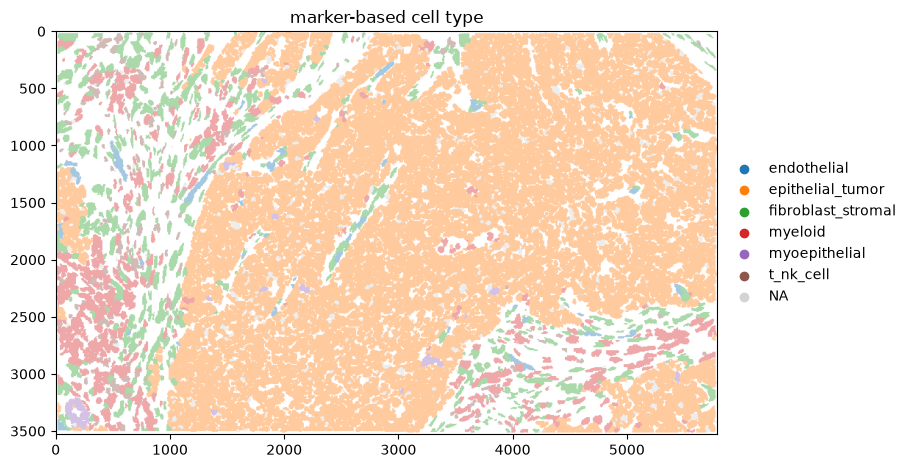

In [4]:
sdata["table"].obs["cell_type"] = pd.Categorical(adata.obs["cell_type"].reindex(sdata["table"].obs_names))

sdata.pl.render_labels("cell_labels", color="cell_type").pl.show(
    coordinate_systems="global", title="marker-based cell type", figsize=(9, 6)
)


## 2. The graph, again

The spatial graph is the model: it encodes your assumption about what "nearby" means, and
every downstream result inherits it. Build the same tissue four ways and look at what
changes: the number of niches, or only where their boundaries fall?


In [5]:
graph_variants = {
    "knn6": dict(fn=sq.gr.spatial_neighbors_knn, kwargs=dict(n_neighs=6)),
    "knn30": dict(fn=sq.gr.spatial_neighbors_knn, kwargs=dict(n_neighs=30)),
    "radius30um": dict(fn=sq.gr.spatial_neighbors_radius, kwargs=dict(radius=30.0)),
    "delaunay": dict(fn=sq.gr.spatial_neighbors_delaunay, kwargs=dict()),
    "delaunay_trimmed_p99": dict(fn=sq.gr.spatial_neighbors_delaunay, kwargs=dict(percentile=99)),
}

for name, spec in graph_variants.items():
    a = adata.copy()
    spec["fn"](a, **spec["kwargs"])
    conn = a.obsp["spatial_connectivities"]
    print(f"{name:<24} {conn.nnz // 2:>6} edges   mean degree {conn.sum(axis=1).mean():.1f}")


INFO     Creating graph using `None` transform and `1` libraries.                                                  


knn6                      20718 edges   mean degree 6.0
INFO     Creating graph using `None` transform and `1` libraries.                                                  


knn30                    103590 edges   mean degree 30.0
INFO     Creating graph using `None` transform and `1` libraries.                                                  


radius30um                78046 edges   mean degree 22.6
INFO     Creating graph using `None` transform and `1` libraries.                                                  


delaunay                  20689 edges   mean degree 6.0
INFO     Creating graph using `None` transform and `1` libraries.                                                  


delaunay_trimmed_p99      20448 edges   mean degree 5.9


Delaunay triangulates the convex hull of the tissue, so a handful of very long edges jump
across real gaps; the 99th-percentile trim removes them without touching the well-behaved
edges. `radius` and `knn` never had that problem, but pick the wrong number and you either
starve a cell of neighbours or wire it to the whole tissue.

Fix `delaunay_trimmed_p99` as the working graph for the rest of the notebook: it is the
version that best matches what "nearby" means at single-cell resolution here.


In [6]:
sq.gr.spatial_neighbors_delaunay(adata, percentile=99)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


## 3. The niche-detection flavour

Three families of niche detection on the *same* graph: neighbourhood composition, UTAG
(spatially smoothed expression), and CellCharter (clustering a spatially aggregated latent
embedding). CellCharter's embedding is an scVI latent. Training it live is not something 25
people can do on a shared CPU box, so it ships precomputed.


In [7]:
scvi_latent_file = paths.precomputed("xenium_scvi_latent.npy")
scvi_ids_file = paths.precomputed("xenium_scvi_latent_obsnames.csv")

if scvi_latent_file is not None:
    latent = np.load(scvi_latent_file)
    latent_ids = pd.read_csv(scvi_ids_file, index_col=0)["cell_id"].values
    assert (latent_ids == adata.obs["cell_id"].values).all(), "cached latent does not match this object's cell order"
    adata.obsm["X_scVI"] = latent
    print(f"scVI latent loaded from cache: {scvi_latent_file}, shape {latent.shape}")
else:
    # The training call that produced the cache above, left visible but not run live:
    #
    # import scvi
    # scvi.model.SCVI.setup_anndata(adata, layer="counts")
    # model = scvi.model.SCVI(adata, n_latent=10)
    # model.train(max_epochs=200, early_stopping=True)
    # adata.obsm["X_scVI"] = model.get_latent_representation()
    raise FileNotFoundError(
        "xenium_scvi_latent.npy not found in the shared cache or your own outputs/.\n"
        "Ask the instructors: this should ship precomputed."
    )


scVI latent loaded from cache: /opt/workshop/data/precomputed/xenium_scvi_latent.npy, shape (6906, 10)


In [8]:
scaled = adata.copy()
sc.pp.scale(scaled, max_value=10)
sc.pp.pca(scaled, n_comps=50)
sc.pp.neighbors(scaled)
sc.tl.leiden(scaled, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0)
adata.obs["leiden"] = scaled.obs["leiden"]

sq.gr.calculate_niche(adata, flavor="neighborhood", groups="leiden", n_neighbors=15, resolutions=0.005)
sq.gr.calculate_niche(adata, flavor="utag", n_neighbors=15, resolutions=0.55)
sq.gr.calculate_niche(adata, flavor="cellcharter", use_rep="X_scVI", distance=1, aggregation="mean", n_components=10)

niche_cols = {
    "neighborhood": "nhood_niche_res=0.005",
    "utag": "utag_niche_res=0.55",
    "cellcharter": "cellcharter_niche",
}
for name, col in niche_cols.items():
    print(f"{name:<14} K = {adata.obs[col].nunique()}")

print()
print("=== pairwise ARI between flavours ===")
names = list(niche_cols)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        ari = adjusted_rand_score(adata.obs[niche_cols[a]].astype(str), adata.obs[niche_cols[b]].astype(str))
        print(f"{a} vs {b}: ARI = {ari:.3f}")


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


neighborhood   K = 21
utag           K = 8
cellcharter    K = 10

=== pairwise ARI between flavours ===
neighborhood vs utag: ARI = 0.019
neighborhood vs cellcharter: ARI = 0.016
utag vs cellcharter: ARI = 0.207


> **_Question:_** Even after choosing niche counts of similar order of magnitude (8, 10, 21),
> pairwise ARI stays below 0.21. All three methods see the same graph and the same cells, but
> not the same feature space: `neighborhood` clusters the composition of Leiden labels, while
> `utag` and `cellcharter` both start from continuous expression, just transformed
> differently (spatially smoothed expression vs. an scVI embedding of it). The two that share
> a feature space agree at ARI = 0.207; the one that does not agrees with neither (0.019,
> 0.016). What does that tell you about how much a "niche" depends on the *definition* rather
> than the tissue?

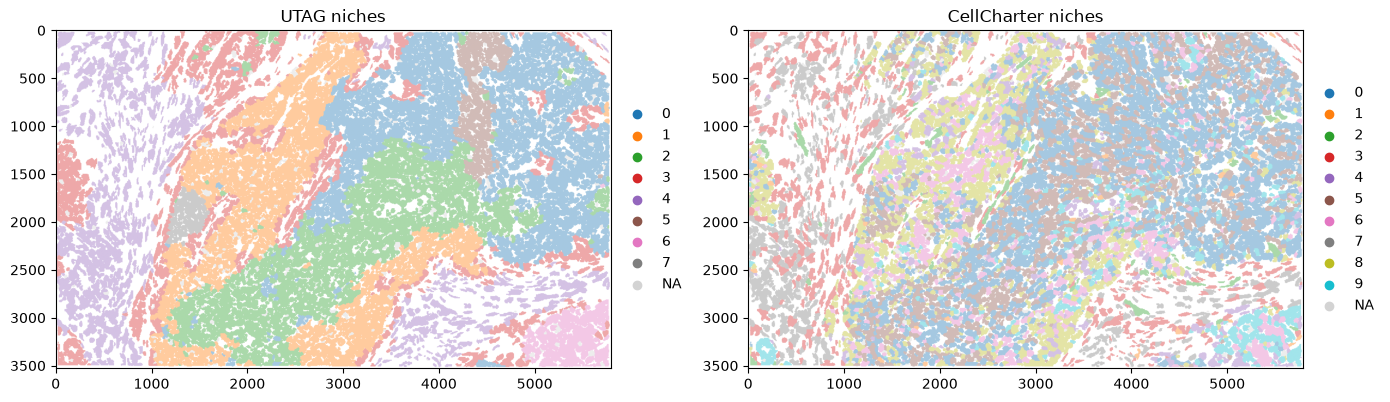

In [9]:
sdata["table"].obs["niche_utag"] = pd.Categorical(
    adata.obs[niche_cols["utag"]].astype(str).reindex(sdata["table"].obs_names)
)
sdata["table"].obs["niche_cellcharter"] = pd.Categorical(
    adata.obs[niche_cols["cellcharter"]].astype(str).reindex(sdata["table"].obs_names)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sdata.pl.render_labels("cell_labels", color="niche_utag").pl.show(ax=axes[0], coordinate_systems="global", title="UTAG niches")
sdata.pl.render_labels("cell_labels", color="niche_cellcharter").pl.show(ax=axes[1], coordinate_systems="global", title="CellCharter niches")
plt.tight_layout()


## 4. Resolution

Tissues are hierarchical: there may be no unequivocal best number of niches, only a
hierarchy of increasingly fine subdivisions. Sweep resolution for the two niche flavours
that take a resolution parameter (`neighborhood` and `utag`; `cellcharter` takes a cluster
count `n_components` directly, not a resolution) and watch the niche count climb: there is
no elbow that says "stop here" for either one.

INFO     Overwriting existing column 'nhood_niche_res=0.005'                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


INFO     Overwriting existing column 'utag_niche_res=0.55'                                                         


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


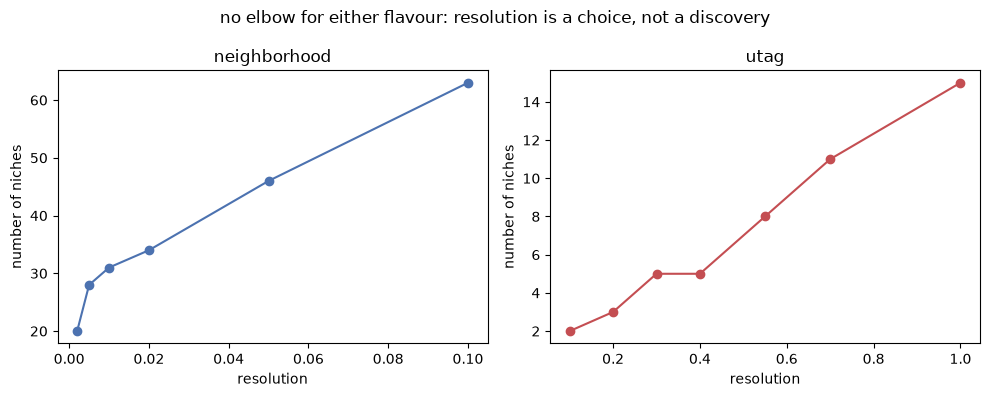

In [10]:
neighborhood_resolutions = [0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
neighborhood_n_niches = []
for res in neighborhood_resolutions:
    a = adata.copy()
    sq.gr.calculate_niche(a, flavor="neighborhood", groups="leiden", n_neighbors=15, resolutions=res)
    neighborhood_n_niches.append(a.obs[f"nhood_niche_res={res}"].nunique())

utag_resolutions = [0.1, 0.2, 0.3, 0.4, 0.55, 0.7, 1.0]
utag_n_niches = []
for res in utag_resolutions:
    a = adata.copy()
    sq.gr.calculate_niche(a, flavor="utag", n_neighbors=15, resolutions=res)
    utag_n_niches.append(a.obs[f"utag_niche_res={res}"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(neighborhood_resolutions, neighborhood_n_niches, marker="o", color="#4C72B0")
axes[0].set_xlabel("resolution"); axes[0].set_ylabel("number of niches")
axes[0].set_title("neighborhood")

axes[1].plot(utag_resolutions, utag_n_niches, marker="o", color="#C44E52")
axes[1].set_xlabel("resolution"); axes[1].set_ylabel("number of niches")
axes[1].set_title("utag")

fig.suptitle('no elbow for either flavour: resolution is a choice, not a discovery')
plt.tight_layout()
plt.show()

The two flavours do not even agree on what a reasonable resolution range looks like:
`neighborhood` needs resolutions two orders of magnitude smaller than `utag` to avoid
exploding into dozens of niches. That mismatch is itself part of the answer to "how much
does a niche depend on the definition": the same word, `resolution`, means something
different in each flavour's own hyperparameter space.

For a different angle on the same question, sweep resolution for plain Leiden clustering
on expression (not a niche flavour at all, just the ordinary clustering used elsewhere in
this notebook for cell typing) and track the evenness of the resulting cluster-size
distribution alongside the cluster count: the Shannon entropy of the cluster sizes,
normalised by the maximum possible entropy for that many clusters (log2(K)), so the value
stays between 0 and 1 regardless of how many clusters there are. Evenness captures something
the niche count alone does not: whether new clusters at a higher resolution are meaningfully
sized subdivisions, or thin slivers carved off a dominant cluster.

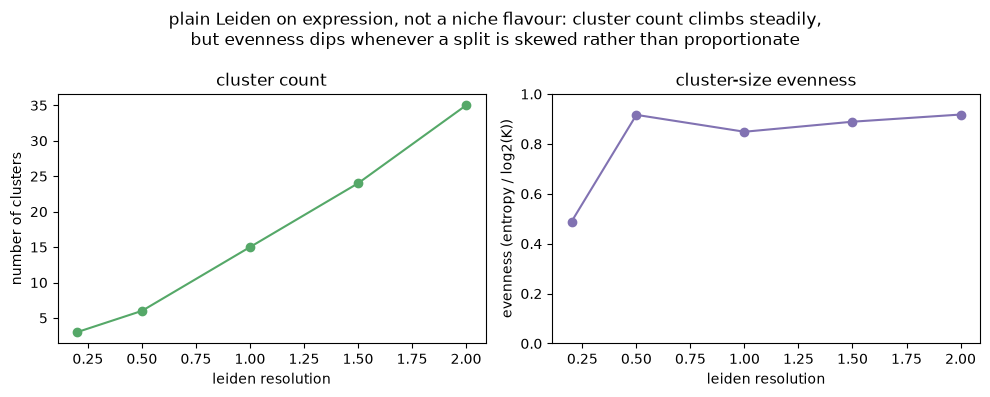

In [11]:
leiden_resolutions = [0.2, 0.5, 1.0, 1.5, 2.0]
leiden_n_clusters, leiden_evenness = [], []
for res in leiden_resolutions:
    a = adata.copy()
    sc.pp.scale(a, max_value=10)
    sc.pp.pca(a, n_comps=50)
    sc.pp.neighbors(a)
    sc.tl.leiden(a, resolution=res, flavor="igraph", n_iterations=2, random_state=0)
    k = a.obs["leiden"].nunique()
    leiden_n_clusters.append(k)
    fractions = a.obs["leiden"].value_counts(normalize=True).values
    entropy = -(fractions * np.log2(fractions)).sum()
    leiden_evenness.append(entropy / np.log2(k))  # normalised to [0, 1]: 1 = perfectly balanced sizes

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(leiden_resolutions, leiden_n_clusters, marker="o", color="#55A868")
axes[0].set_xlabel("leiden resolution"); axes[0].set_ylabel("number of clusters")
axes[0].set_title("cluster count")

axes[1].plot(leiden_resolutions, leiden_evenness, marker="o", color="#8172B2")
axes[1].set_xlabel("leiden resolution"); axes[1].set_ylabel("evenness (entropy / log2(K))")
axes[1].set_title("cluster-size evenness")
axes[1].set_ylim(0, 1)

fig.suptitle("plain Leiden on expression, not a niche flavour: cluster count climbs steadily,\nbut evenness dips whenever a split is skewed rather than proportionate")
plt.tight_layout()
plt.show()

## 5. Evaluating niches, with and without a reference

**Reference-based:** ARI against the marker-based cell type annotation. **Reference-free:**
CHAOS and PAS, written out in full below rather than imported, because the point is seeing
that PAS is nothing more than a neighbour-label comparison. **Stability:** Fowlkes–Mallows
between two Leiden seeds at the same resolution.

First, run CHAOS/PAS on the raw expression (Leiden) clusters: these are *not* spatial
domains, just cell types that happen to be scattered through the tissue, to see what a bad
score looks like. Then run them on the UTAG niches, which are spatially smoothed by
construction.


In [11]:
def pas_score(labels, xy, k=6):
    """Fraction of cells whose own label disagrees with the majority of their k spatial neighbours."""
    tree = cKDTree(xy)
    _, nn_idx = tree.query(xy, k=k + 1)
    nn_idx = nn_idx[:, 1:]  # drop self
    neighbor_labels = labels[nn_idx]
    agree_frac = (neighbor_labels == labels[:, None]).mean(axis=1)
    return (agree_frac < 0.5).mean()


def chaos_score(labels, xy):
    """Size-weighted mean nearest-neighbour distance within each cluster, in the coordinate units (um)."""
    per_cluster, sizes = [], []
    for cl in pd.unique(labels):
        idx = np.where(labels == cl)[0]
        if len(idx) < 2:
            continue
        d, _ = cKDTree(xy[idx]).query(xy[idx], k=2)
        per_cluster.append(d[:, 1].mean())
        sizes.append(len(idx))
    return np.average(per_cluster, weights=sizes)


xy = adata.obsm["spatial"]

for name, labels in [
    ("leiden (expression, not spatial)", adata.obs["leiden"].values),
    ("utag niche", adata.obs[niche_cols["utag"]].values),
    ("cellcharter niche", adata.obs[niche_cols["cellcharter"]].values),
]:
    print(f"{name:<34} PAS={pas_score(labels, xy):.3f}   CHAOS={chaos_score(labels, xy):.1f} um")


leiden (expression, not spatial)   PAS=0.692   CHAOS=15.2 um
utag niche                         PAS=0.061   CHAOS=8.9 um
cellcharter niche                  PAS=0.509   CHAOS=12.7 um


> **_Question:_** PAS on the raw expression clusters is close to 0.5, coin-flip agreement
> with your spatial neighbours. Why would that be true even for a *correct* clustering of
> cell types, and what does it tell you about what PAS is actually measuring?


In [12]:
ari_ref = adjusted_rand_score(
    adata.obs["cell_type"].astype(str), adata.obs[niche_cols["utag"]].astype(str)
)
print(f"ARI(cell_type, utag niche) = {ari_ref:.3f}")

def leiden_with_seed(a, seed):
    a = a.copy()
    sc.pp.scale(a, max_value=10)
    sc.pp.pca(a, n_comps=50)
    sc.pp.neighbors(a)
    sc.tl.leiden(a, resolution=1.0, flavor="igraph", n_iterations=2, random_state=seed)
    return a.obs["leiden"]

leiden_seed0 = leiden_with_seed(adata, 0)
leiden_seed1 = leiden_with_seed(adata, 1)
fm = fowlkes_mallows_score(leiden_seed0, leiden_seed1)
print(f"Fowlkes-Mallows (seed 0 vs seed 1, same resolution) = {fm:.3f}")


ARI(cell_type, utag niche) = 0.117


Fowlkes-Mallows (seed 0 vs seed 1, same resolution) = 0.735


The low ARI against cell type is expected and not a failure: a niche is defined by *mixture*,
so a good niche often spans several cell types and scores as "error" against a coarser
reference. That is the catch with reference-based metrics: the reference is
usually coarser than the clustering.


## 6. From a niche label to a described niche

A niche number is not biology until you describe what is *in* it. Two views of the same
question: `nhood_enrichment` (do labels sit next to each other more than chance?) and a
straightforward composition crosstab (what fraction of each niche is which cell type?).


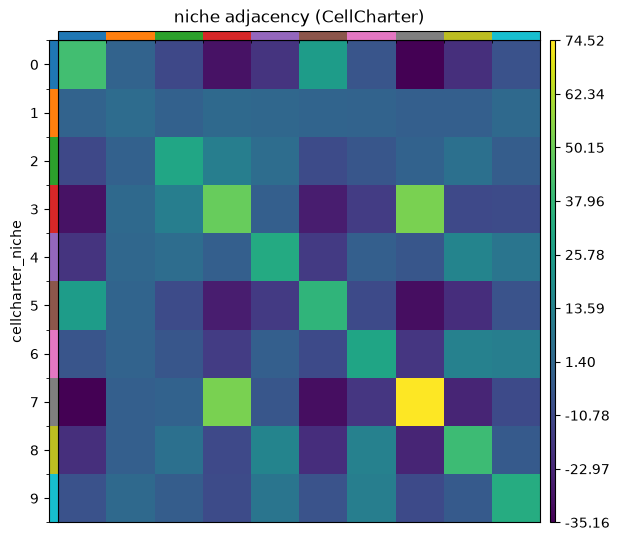

In [13]:
sq.gr.nhood_enrichment(adata, cluster_key=niche_cols["cellcharter"], seed=0, show_progress_bar=False)
sq.pl.nhood_enrichment(adata, cluster_key=niche_cols["cellcharter"], figsize=(6, 5), title="niche adjacency (CellCharter)")
plt.show()


In [14]:
composition = (
    pd.crosstab(adata.obs[niche_cols["cellcharter"]], adata.obs["cell_type"], normalize="index")
    .round(2)
)
composition


cell_type,endothelial,epithelial_tumor,fibroblast_stromal,myeloid,myoepithelial,t_nk_cell
cellcharter_niche,,,,,,
0,0.00,1.00,0.00,0.00,0.00,0.00
1,0.00,0.65,0.35,0.00,0.00,0.00
2,0.46,0.16,0.38,0.01,0.00,0.00
3,0.00,0.00,0.85,0.14,0.00,0.01
4,0.00,0.66,0.01,0.32,0.00,0.00
5,0.00,1.00,0.00,0.00,0.00,0.00
6,0.00,0.98,0.00,0.00,0.02,0.00
7,0.00,0.00,0.02,0.68,0.00,0.30
8,0.00,0.98,0.02,0.00,0.00,0.00


### Exercise

Repeat the flavour comparison (section 3) using the `knn30` graph from section 2 instead of
`delaunay_trimmed_p99`. Does the pairwise ARI between flavours go up or down? Is the change
bigger than the disagreement between flavours on the same graph?


In [15]:
# your answer here


## Pitfalls

- **Cell type labels and niches answer different questions.** A niche can legitimately mix
  several cell types; scoring it against a cell-type reference will always look worse than
  it is.
- **Small marker gene sets are noisy on an imaging panel.** Score at the cluster level, not
  the cell level, and check the top differentially expressed genes before trusting a label;
  see the fallback rule in section 1.
- **The graph, the flavour, and the resolution are three independent hyperparameters.**
  Report all three, with their values, whenever you report a niche count.
- **CHAOS and PAS reward smooth labels.** A clustering that ignores expression entirely and
  just draws contiguous blobs will score well on both. They are necessary checks, not
  sufficient ones.

## Further reading

- [Spatial domains, Single-cell best practices](https://www.sc-best-practices.org/spatial/domains/) and `sq.gr.calculate_niche`
- [CellCharter (Varrone et al. 2024, *Nature Genetics*)](https://www.nature.com/articles/s41588-023-01588-4)
- UTAG (Kim et al. 2024), and the expert-guided consensus benchmark (Beyond benchmarking:
  an expert-guided consensus approach to spatially aware clustering, Nature Methods, 2026)
